# AMI Dataset Explorer

AMI IHM (Individual Headset Microphone) corpus завантажений у форматі HuggingFace Arrow.  
Splits: **136 train / 18 val / 16 test**  
Поля кожного запису: `audio` (waveform + sr), `timestamps_start`, `timestamps_end`, `speakers`

In [1]:
import datasets
from datasets import Audio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import IPython.display as ipd
import soundfile as sf
import io

DATA_DIR = "ami_data"

def decode_audio(example):
    """Декодує аудіо з байтів через soundfile, повертає (array, sr)."""
    raw = example['audio']
    audio_bytes = raw.get('bytes') or open(raw['path'], 'rb').read()
    array, sr = sf.read(io.BytesIO(audio_bytes), dtype='float32', always_2d=False)
    return array, sr

## 1. Завантаження датасету

In [2]:
from pathlib import Path

def load_ami(data_dir):
    data_dir = Path(data_dir)
    splits = {}
    for split_name, prefix in [('train', 'train'), ('validation', 'validation'), ('test', 'test')]:
        shards = sorted(data_dir.glob(f"ami-{prefix}-*.arrow"))
        parts = [datasets.Dataset.from_file(str(f)) for f in shards]
        ds_split = datasets.concatenate_datasets(parts)
        # вимикаємо авто-декодинг — декодуємо вручну через soundfile
        ds_split = ds_split.cast_column("audio", Audio(decode=False))
        splits[split_name] = ds_split
    return datasets.DatasetDict(splits)

ds = load_ami(DATA_DIR)
print(ds)
print("\nFeatures:", ds['train'].features)

DatasetDict({
    train: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 136
    })
    validation: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 18
    })
    test: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 16
    })
})

Features: {'audio': Audio(sampling_rate=None, decode=False, num_channels=None, stream_index=None), 'timestamps_start': List(Value('float64')), 'timestamps_end': List(Value('float64')), 'speakers': List(Value('string'))}


## 2. Загальна статистика по кожному split

In [3]:
for split_name in ['train', 'validation', 'test']:
    split = ds[split_name]
    durations = []
    n_speakers_list = []
    n_segments_list = []

    for example in split:
        array, sr = decode_audio(example)
        durations.append(len(array) / sr)
        n_speakers_list.append(len(set(example['speakers'])))
        n_segments_list.append(len(example['timestamps_start']))

    print(f"\n{'='*40}")
    print(f"Split: {split_name}  ({len(split)} recordings)")
    print(f"  Duration: min={min(durations)/60:.1f} max={max(durations)/60:.1f} mean={np.mean(durations)/60:.1f} min")
    print(f"  Total audio: {sum(durations)/3600:.2f} hours")
    print(f"  Speakers per recording: min={min(n_speakers_list)} max={max(n_speakers_list)} mean={np.mean(n_speakers_list):.1f}")
    print(f"  Segments per recording: min={min(n_segments_list)} max={max(n_segments_list)} mean={np.mean(n_segments_list):.0f}")


Split: train  (136 recordings)
  Duration: min=8.0 max=90.3 mean=35.6 min
  Total audio: 80.67 hours
  Speakers per recording: min=3 max=5 mean=4.0
  Segments per recording: min=76 max=1195 mean=491

Split: validation  (18 recordings)
  Duration: min=15.7 max=49.5 mean=32.2 min
  Total audio: 9.67 hours
  Speakers per recording: min=4 max=4 mean=4.0
  Segments per recording: min=169 max=921 mean=481

Split: test  (16 recordings)
  Duration: min=14.0 max=49.5 mean=34.0 min
  Total audio: 9.06 hours
  Speakers per recording: min=3 max=4 mean=3.9
  Segments per recording: min=195 max=746 mean=468


## 3. Детальний перегляд одного запису

In [4]:
SPLIT = 'train'
IDX   = 0

ex = ds[SPLIT][IDX]
audio_array, sr = decode_audio(ex)
starts   = ex['timestamps_start']
ends     = ex['timestamps_end']
speakers = ex['speakers']
duration = len(audio_array) / sr

unique_spk = sorted(set(speakers))
spk2color  = {s: plt.cm.tab10(i / len(unique_spk)) for i, s in enumerate(unique_spk)}

print(f"Recording #{IDX} [{SPLIT}]")
print(f"  Duration : {duration/60:.2f} min")
print(f"  SR       : {sr} Hz")
print(f"  Segments : {len(starts)}")
print(f"  Speakers : {unique_spk}")

Recording #0 [train]
  Duration : 34.68 min
  SR       : 16000 Hz
  Segments : 455
  Speakers : ['MIE029', 'MIE080', 'MIE083', 'MIO026']


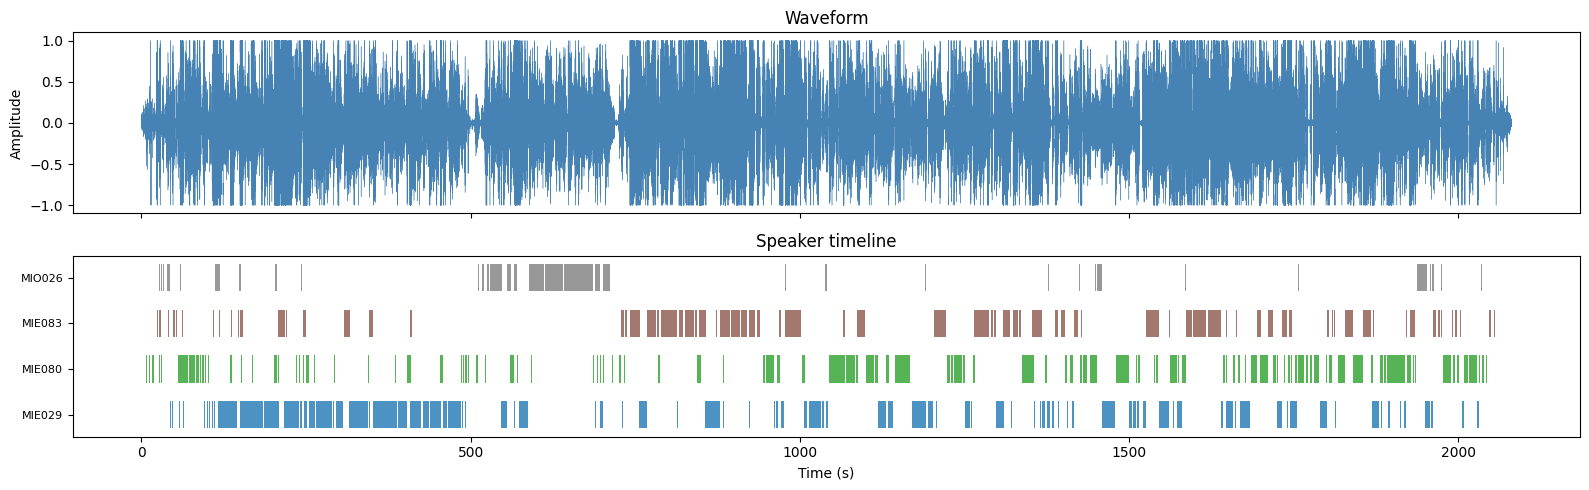

In [5]:
# Waveform + speaker timeline
fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)

# Waveform
t = np.linspace(0, duration, len(audio_array))
axes[0].plot(t, audio_array, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Waveform')

# Speaker timeline
for i, spk in enumerate(unique_spk):
    segs = [(s, e) for s, e, sp in zip(starts, ends, speakers) if sp == spk]
    for s, e in segs:
        axes[1].barh(i, e - s, left=s, height=0.6, color=spk2color[spk], alpha=0.8)

axes[1].set_yticks(range(len(unique_spk)))
axes[1].set_yticklabels(unique_spk, fontsize=8)
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Speaker timeline')

plt.tight_layout()
plt.show()

## 4. VAD-мітка: скільки часу тиша vs мовлення

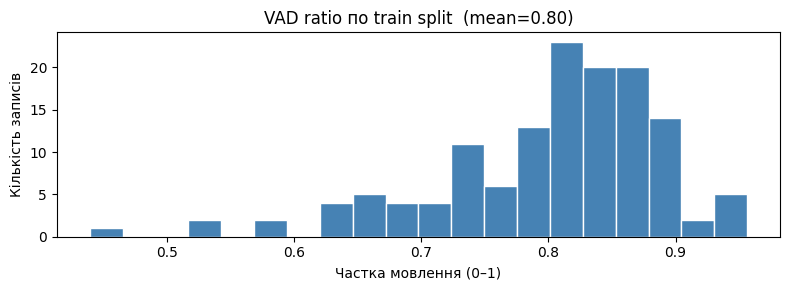

In [6]:
def compute_vad_ratio(example):
    array, sr = decode_audio(example)
    duration = len(array) / sr
    frame_ms = 10
    n_frames = int(duration * 1000 / frame_ms)
    vad = np.zeros(n_frames, dtype=bool)
    for s, e in zip(example['timestamps_start'], example['timestamps_end']):
        fs = int(s * 1000 / frame_ms)
        fe = int(e * 1000 / frame_ms)
        vad[fs:fe] = True
    return vad.mean()

speech_ratios = [compute_vad_ratio(ex) for ex in ds['train']]

plt.figure(figsize=(8, 3))
plt.hist(speech_ratios, bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Частка мовлення (0–1)')
plt.ylabel('Кількість записів')
plt.title(f'VAD ratio по train split  (mean={np.mean(speech_ratios):.2f})')
plt.tight_layout()
plt.show()

## 5. Розподіл кількості мовців по записах

In [7]:
for split_name in ['train', 'validation', 'test']:
    counts = Counter(len(set(ex['speakers'])) for ex in ds[split_name])
    print(f"{split_name}: {dict(sorted(counts.items()))} (n_speakers → count)")

train: {3: 4, 4: 129, 5: 3} (n_speakers → count)
validation: {4: 18} (n_speakers → count)
test: {3: 1, 4: 15} (n_speakers → count)


## 6. Довжини сегментів (для вибору розміру чанка)

Segments: 66816
  min=0.03s  max=82.50s
  mean=4.08s  median=1.52s


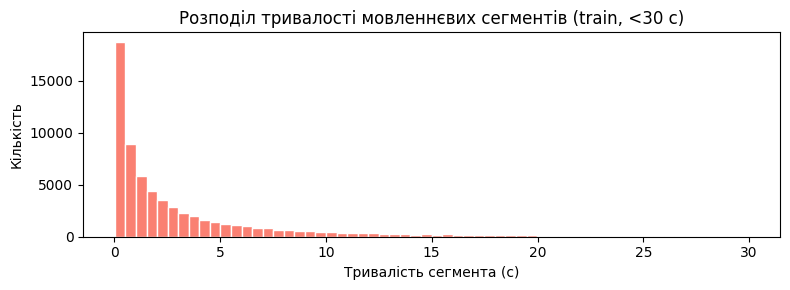

In [8]:
seg_durations = []
for ex in ds['train']:
    for s, e in zip(ex['timestamps_start'], ex['timestamps_end']):
        seg_durations.append(e - s)

seg_durations = np.array(seg_durations)
print(f"Segments: {len(seg_durations)}")
print(f"  min={seg_durations.min():.2f}s  max={seg_durations.max():.2f}s")
print(f"  mean={seg_durations.mean():.2f}s  median={np.median(seg_durations):.2f}s")

plt.figure(figsize=(8, 3))
plt.hist(seg_durations[seg_durations < 30], bins=60, color='salmon', edgecolor='white')
plt.xlabel('Тривалість сегмента (с)')
plt.ylabel('Кількість')
plt.title('Розподіл тривалості мовленнєвих сегментів (train, <30 с)')
plt.tight_layout()
plt.show()

## 7. Прослухати фрагмент

In [9]:
START_SEC = 0
END_SEC   = 30

clip = audio_array[int(START_SEC * sr): int(END_SEC * sr)]
ipd.display(ipd.Audio(clip, rate=sr))